## ChebKAN

In [ ]:

import math

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch
from chebytest import ChebyKANLayer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from datetime import datetime
from tqdm import tqdm
from torch.optim import LBFGS
import torch.nn as nn


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

EPOCHS = 100
TRIALS = 1000

MAX_DEPTH = 20
MAX_NEURONS = 200

DATA = 'CA'
# data = pd.read_csv("../DATA/%s.csv" % DATA)
data = pd.read_csv("/home/data3/Ali/Code/KAN/Afzal/DATA/%s.csv" % DATA)

data.fillna(0, inplace=True)
y = data["target_label"].values
data.drop("target_label", axis=1, inplace=True)
X = data.values.astype(np.float32)

if y.dtype == "object":
    label_encoder = LabelEncoder()
    y = torch.tensor(label_encoder.fit_transform(y))
else:
    y = torch.tensor(y)


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, stratify=y_train, test_size=0.1, random_state=42)

scaler = StandardScaler()
X_train = torch.tensor(scaler.fit_transform(X_train)).to(device)
X_valid = torch.tensor(scaler.transform(X_valid)).to(device)
X_test = torch.tensor(scaler.transform(X_test)).to(device)

y_train = torch.nn.functional.one_hot(y_train.long(), num_classes=2).to(device).float()
y_valid = torch.nn.functional.one_hot(y_valid.long(), num_classes=2).to(device).float()
y_test = torch.nn.functional.one_hot(y_test.long(), num_classes=2).to(device).float()


input_shape = X_train.shape[1]
output_shape = y_train.shape[1]

print("Reduce number of features from %d to %d." % (data.shape[1], input_shape))

dataset = {
    "train_input": X_train,
    "train_label": y_train,
    "test_input": X_valid,
    "test_label": y_valid,
}


def fit(model, dataset, steps=100, loss_fn=None, lr=1., batch=-1):
    pbar = tqdm(range(steps), desc='description', ncols=100)
    optimizer = LBFGS(model.parameters(), lr=lr, history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-32, tolerance_change=1e-32)

    results = {}
    results['train_loss'] = []
    results['test_loss'] = []

    if batch == -1 or batch > dataset['train_input'].shape[0]:
        batch_size = dataset['train_input'].shape[0]
        batch_size_test = dataset['test_input'].shape[0]
    else:
        batch_size = batch
        batch_size_test = batch

    global train_loss

    def closure():
        global train_loss
        optimizer.zero_grad()
        pred = model.forward(dataset['train_input'][train_id])
        train_loss = loss_fn(pred, dataset['train_label'][train_id])
        objective = train_loss
        objective.backward()
        return objective

    for _ in pbar:


        train_id = np.random.choice(dataset['train_input'].shape[0], batch_size, replace=False)
        test_id = np.random.choice(dataset['test_input'].shape[0], batch_size_test, replace=False)

        optimizer.step(closure)

        test_loss = loss_fn(model.forward(dataset['test_input'][test_id]), dataset['test_label'][test_id])

        results['train_loss'].append(torch.sqrt(train_loss).cpu().detach().numpy())
        results['test_loss'].append(torch.sqrt(test_loss).cpu().detach().numpy())
        pbar.set_description("| train_loss: %.2e | test_loss: %.2e " % (torch.sqrt(train_loss).cpu().detach().numpy(), torch.sqrt(test_loss).cpu().detach().numpy()))

    return results


class fKAN(nn.Module):
    def __init__(self, layers, orders):
        super(fKAN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 2):
            self.layers.append(ChebyKANLayer(layers[i], layers[i + 1], orders[i]))
        self.layers.append(nn.Linear(layers[len(layers) - 2], layers[len(layers) - 1]))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


def objective(trial):
    depth = trial.suggest_int("depth", 1, MAX_DEPTH)

    width = [trial.suggest_int(f"neurons_layer_{i}", 5, MAX_NEURONS, step=5) for i in range(depth)]
    orders = [trial.suggest_int(f"orders_layer_{i}", 2, 6) for i in range(depth)]
    width = [input_shape] + width + [output_shape]
    model = fKAN(width, orders).to(device)

    history = fit(model, dataset, steps=EPOCHS, loss_fn=torch.nn.CrossEntropyLoss())

    y_score = model(X_valid).cpu()
    y_pred = (y_score > 0.5).int()

    return f1_score(y_valid.cpu(), y_pred, average="macro")


best_params = {
    "depth": 3,
    "neurons_layer_0": 65,
    "neurons_layer_1": 130,
    "neurons_layer_2": 130,
    "orders_layer_0": 2,
    "orders_layer_1": 6,
    "orders_layer_2": 2,
}

print('best_params:', best_params)
depth = best_params["depth"]
width = [best_params[f"neurons_layer_{i}"] for i in range(depth)]
width = [input_shape] + width + [output_shape]
orders = [best_params[f"orders_layer_{i}"] for i in range(depth)]

model = fKAN(width, orders).to(device)
history = fit(model, dataset, steps=EPOCHS, loss_fn=torch.nn.CrossEntropyLoss())

y_score = model(X_test).cpu()
y_pred = (y_score > 0.5).int()


print(classification_report(y_test.cpu(), y_pred, target_names=label_encoder.classes_))
print("ROC-AUC: %.4f" % roc_auc_score(y_test.cpu(), y_pred))


In [11]:
X_test.shape
y_score = model(X_test).cpu()
y_pred = (y_score > 0.5).int()

In [15]:
import torch

# Function to calculate SHAP values
def calculate_shap_values(model, X, baseline=None):
    """
    Calculates SHAP values for a classification model.
    
    Parameters:
        model: Trained PyTorch model
        X: Input data (Tensor)
        baseline: Baseline value (Tensor) to compare against. Default is the mean of X.
    
    Returns:
        shap_values: SHAP values (Tensor) with the same shape as X.
    """
    if baseline is None:
        baseline = torch.mean(X, dim=0)  # Default baseline is the mean of X

    shap_values = torch.zeros_like(X).cpu()

    for i in range(X.shape[1]):  # Iterate over each feature
        # Create perturbed versions of X with and without the feature
        X_with_feature = X.clone()
        X_without_feature = X.clone()
        X_without_feature[:, i] = baseline[i]  # Replace feature with baseline value

        # Get model predictions
        with_feature = model(X_with_feature).cpu().detach()[:, 1]  # Focus on class 1 probability
        without_feature = model(X_without_feature).cpu().detach()[:, 1]

        # Calculate the difference in predictions
        shap_values[:, i] = (with_feature - without_feature)

    return shap_values

# Calculate SHAP values for the test set
shap_values = calculate_shap_values(model, X_test)

# Print SHAP values
print("SHAP Values Shape:", shap_values.shape)


SHAP Values Shape: torch.Size([154, 49])


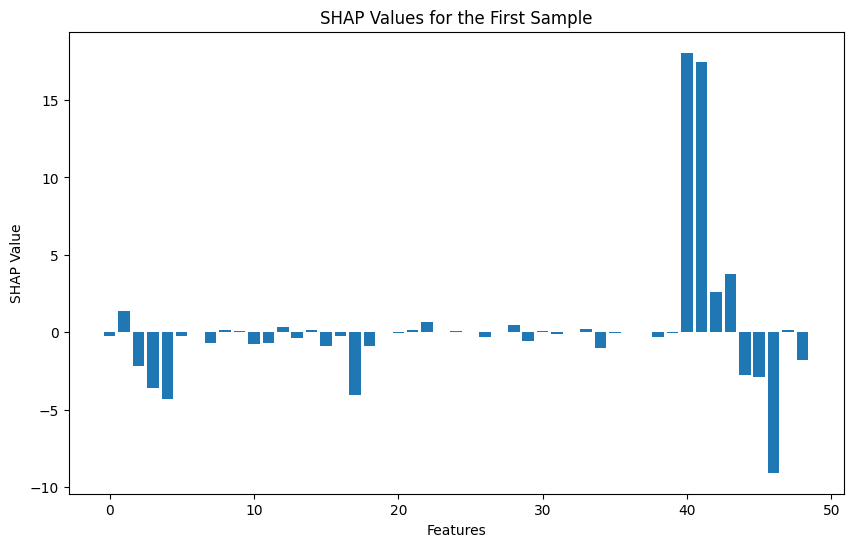

In [16]:
import matplotlib.pyplot as plt

# Plot SHAP values for the first test sample
plt.figure(figsize=(10, 6))
plt.bar(range(shap_values.shape[1]), shap_values[0].numpy())
plt.title('SHAP Values for the First Sample')
plt.xlabel('Features')
plt.ylabel('SHAP Value')
plt.show()
